# Sargazo Classification - ESCOM Redes Competition

Clasificacion multiclase ordinal para estimar el nivel de sargazo en playas del Caribe
mexicano a partir de imagenes extraidas de redes sociales.

| Etiqueta | Clase     |
| -------- | --------- |
| 0        | Nada      |
| 1        | Bajo      |
| 2        | Moderado  |
| 3        | Abundante |
| 4        | Excesivo  |

**Metrica principal:** Quadratic Weighted Kappa (QWK)  
**Hardware objetivo:** NVIDIA RTX 5080 Laptop (16 GB VRAM)


In [18]:
import os
import warnings
from dotenv import load_dotenv
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, cohen_kappa_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

import torchvision.models as models
import torchvision.transforms as transforms

warnings.filterwarnings("ignore")
print("Libraries loaded successfully.")
print("Cuda available:", torch.cuda.is_available())

Libraries loaded successfully.
Cuda available: True


In [19]:
load_dotenv(override=True)

DATA_DIR = os.getenv("DATA_DIR", ".")
IMAGES_DIR = os.path.join(DATA_DIR, "images")
LABELS_CSV = os.path.join(DATA_DIR, "labels", "labels.csv")
TEST_CSV = os.path.join(DATA_DIR, "labels", "test.csv")
BEST_MODEL = "best_model.pth"
SUBMISSION = "submission.csv"

BATCH_SIZE = int(os.getenv("BATCH_SIZE", "256"))
LR_HEAD = float(os.getenv("LR_HEAD", "1e-4"))
LR_BACKBONE = float(os.getenv("LR_BACKBONE", "1e-5"))
PHASE1_EPOCHS = int(os.getenv("PHASE1_EPOCHS", "10"))
PHASE2_EPOCHS = int(os.getenv("PHASE2_EPOCHS", "40"))
PATIENCE = int(os.getenv("PATIENCE", "7"))
NUM_CLASSES = int(os.getenv("NUM_CLASSES", "5"))
SEED = int(os.getenv("SEED", "42"))
NUM_WORKERS = min(8, os.cpu_count() - 1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

if device.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()


def monitor_gpu_memory():
    if not torch.cuda.is_available():
        return
    alloc = torch.cuda.memory_allocated() / 1e9
    reserv = torch.cuda.memory_reserved() / 1e9
    peak = torch.cuda.max_memory_allocated() / 1e9
    print(
        f"GPU Memoria -> Asignada: {alloc:.2f} GB | Reservada: {reserv:.2f} GB | Pico: {peak:.2f} GB"
    )
    if alloc > 14:
        print("  Advertencia: cerca del limite, considera reducir BATCH_SIZE")


print(f"DATA_DIR     : {DATA_DIR}")
print(f"BATCH_SIZE   : {BATCH_SIZE}")
print(f"LR_HEAD      : {LR_HEAD}")
print(f"LR_BACKBONE  : {LR_BACKBONE}")
print(f"PHASE1_EPOCHS: {PHASE1_EPOCHS} | PHASE2_EPOCHS: {PHASE2_EPOCHS}")
print(f"PATIENCE     : {PATIENCE} | NUM_CLASSES: {NUM_CLASSES} | SEED: {SEED}")
print(f"NUM_WORKERS  : {NUM_WORKERS}")
print(f"Device       : {device}")
if device.type == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(
        f"VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
    )
    monitor_gpu_memory()

DATA_DIR     : C:\Users\jlflo\Documents\Datasets\nivel-de-sargazo-26-a
BATCH_SIZE   : 256
LR_HEAD      : 0.0001
LR_BACKBONE  : 1e-05
PHASE1_EPOCHS: 10 | PHASE2_EPOCHS: 40
PATIENCE     : 7 | NUM_CLASSES: 5 | SEED: 42
NUM_WORKERS  : 8
Device       : cuda
GPU          : NVIDIA GeForce RTX 5080 Laptop GPU
VRAM         : 17.09 GB
GPU Memoria -> Asignada: 0.20 GB | Reservada: 0.23 GB | Pico: 0.20 GB


## 1. ETL - Carga de Datos y Preprocesamiento


In [20]:
LABEL_MAP = {
    "nada": 0,
    "bajo": 1,
    "moderado": 2,
    "abundante": 3,
    "excesivo": 4,
}

df = pd.read_csv(LABELS_CSV)
df["nivel"] = df["label"].map(LABEL_MAP)

print(f"Total imagenes de entrenamiento: {len(df)}")
print("Distribucion de clases:")
for name, code in sorted(LABEL_MAP.items(), key=lambda x: x[1]):
    print(f"  {code} - {name:12s}: {(df["label"] == name).sum()} imagenes")

df_train, df_val = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df["nivel"]
)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

print(f"Train: {len(df_train)} imagenes | Validacion: {len(df_val)} imagenes")

Total imagenes de entrenamiento: 2472
Distribucion de clases:
  0 - nada        : 1180 imagenes
  1 - bajo        : 711 imagenes
  2 - moderado    : 227 imagenes
  3 - abundante   : 148 imagenes
  4 - excesivo    : 206 imagenes
Train: 1977 imagenes | Validacion: 495 imagenes


<Axes: xlabel='label'>

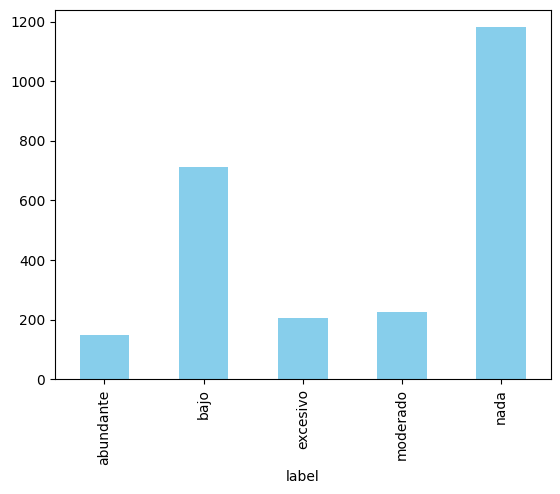

In [21]:
df["label"].value_counts().sort_index().plot(kind="bar", color="skyblue")

In [22]:
classes = np.unique(df_train["label"])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=df_train["label"].values,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Pesos de clase (frecuencia inversa):")
for name, code in sorted(LABEL_MAP.items(), key=lambda x: x[1]):
    print(f"  {code} - {name:12s}: {class_weights[code]:.4f}")

Pesos de clase (frecuencia inversa):
  0 - nada        : 3.3508
  1 - bajo        : 0.6949
  2 - moderado    : 2.3964
  3 - abundante   : 2.1845
  4 - excesivo    : 0.4189


In [23]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

val_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)


class SargazoDataset(Dataset):
    def __init__(self, dataframe, images_dir, transform=None, is_test=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = os.path.join(self.images_dir, row["image_path"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.is_test:
            return image, row["image_path"]
        return image, int(row["nivel"])


print("SargazoDataset y transformaciones definidas.")

SargazoDataset y transformaciones definidas.


In [24]:
train_dataset = SargazoDataset(df_train, IMAGES_DIR, transform=train_transforms)
val_dataset = SargazoDataset(df_val, IMAGES_DIR, transform=val_transforms)

_persistent = NUM_WORKERS > 0
_prefetch = 2 if NUM_WORKERS > 0 else None

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    persistent_workers=_persistent,
    prefetch_factor=_prefetch,
    drop_last=False,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    persistent_workers=_persistent,
    prefetch_factor=_prefetch,
)

print(f"Batches de entrenamiento : {len(train_loader)}")
print(f"Batches de validacion    : {len(val_loader)}")
print(f"persistent_workers       : {_persistent}")
print(f"prefetch_factor          : {_prefetch}")

Batches de entrenamiento : 8
Batches de validacion    : 2
persistent_workers       : True
prefetch_factor          : 2


## 2. Arquitectura del Modelo - Transfer Learning con ResNet-50


In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

for param in model.parameters():
    param.requires_grad = False

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, NUM_CLASSES)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parametros totales     : {total_params:,}")
print(f"Parametros entrenables : {trainable_params:,}")

# torch.compile se prueba con un forward real dentro del try porque la
# compilacion es lazy: el error de Triton ocurre en el primer forward, no
# en la llamada a torch.compile().
_base_model = model
for _mode in ["max-autotune", "default"]:
    try:
        _candidate = torch.compile(_base_model, mode=_mode)
        _dummy = torch.randn(2, 3, 224, 224, device=device)
        with torch.no_grad():
            _ = _candidate(_dummy)
        del _dummy
        model = _candidate
        print(f"Modelo compilado con torch.compile (modo: {_mode})")
        break
    except Exception:
        continue
else:
    model = _base_model
    print("torch.compile no disponible en este entorno, usando modelo sin compilar")

# Verificacion GPU: medir pico de memoria en un forward aislado
torch.cuda.reset_peak_memory_stats()
_test = torch.randn(min(BATCH_SIZE, 8), 3, 224, 224, device=device)
torch.cuda.synchronize()
with torch.no_grad():
    _ = model(_test)
torch.cuda.synchronize()
peak = torch.cuda.max_memory_allocated() / 1e9
del _test

print(f"Modelo en GPU            : {next(model.parameters()).is_cuda}")
print(f"Peak memory forward pass : {peak:.2f} GB")
monitor_gpu_memory()

Parametros totales     : 23,518,277
Parametros entrenables : 10,245
torch.compile no disponible en este entorno, usando modelo sin compilar
Modelo en GPU            : True
Peak memory forward pass : 2.67 GB
GPU Memoria -> Asignada: 0.21 GB | Reservada: 0.32 GB | Pico: 2.67 GB


## 3. Estrategia de Entrenamiento


In [26]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

scaler = GradScaler(device.type, growth_interval=2000)
print("Criterio, optimizador, scheduler y GradScaler inicializados.")

Criterio, optimizador, scheduler y GradScaler inicializados.


In [27]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=device.type, dtype=torch.bfloat16):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)
        preds = outputs.detach().argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    return avg_loss, f1, qwk


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Eval ", leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast(device_type=device.type, dtype=torch.bfloat16):
                outputs = model(images)
                loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    return avg_loss, f1, qwk


def run_training(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    scaler,
    device,
    num_epochs,
    patience,
    history,
    best_state,
):
    patience_counter = 0
    best_qwk = best_state["best_qwk"]

    print(
        "Epoch | Train Loss | Train F1 | Train QWK |  Val Loss |  Val F1 |  Val QWK |        LR"
    )
    print("-" * 93)

    for epoch in range(1, num_epochs + 1):
        train_loss, train_f1, train_qwk = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device
        )
        val_loss, val_f1, val_qwk = evaluate(model, val_loader, criterion, device)
        current_lr = optimizer.param_groups[0]["lr"]
        global_epoch = len(history) + 1
        scheduler.step(val_qwk)

        history.append(
            {
                "epoch": global_epoch,
                "train_loss": train_loss,
                "train_f1": train_f1,
                "train_qwk": train_qwk,
                "val_loss": val_loss,
                "val_f1": val_f1,
                "val_qwk": val_qwk,
                "lr": current_lr,
            }
        )

        print(
            f"{global_epoch:5d} | {train_loss:10.4f} | {train_f1:8.4f} | {train_qwk:9.4f} |"
            f" {val_loss:9.4f} | {val_f1:7.4f} | {val_qwk:8.4f} | {current_lr:9.2e}"
        )

        if val_qwk > best_qwk:
            best_qwk = val_qwk
            patience_counter = 0
            torch.save(model.state_dict(), BEST_MODEL)
            print(f"         >> Mejor modelo guardado (Val QWK={best_qwk:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping en epoca {global_epoch}.")
                break

    best_state["best_qwk"] = best_qwk
    return history, best_state


print("Funciones de entrenamiento definidas.")

Funciones de entrenamiento definidas.


### Fase 1: Entrenamiento de la Cabeza de Clasificacion (backbone congelado)


In [ ]:
history = []
best_state = {"best_qwk": -1.0}

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(
    f"Fase 1: {PHASE1_EPOCHS} epocas | backbone congelado | parametros entrenables: {trainable:,}"
)
print()

history, best_state = run_training(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    scaler,
    device,
    PHASE1_EPOCHS,
    PATIENCE,
    history,
    best_state,
)

phase1_best = best_state["best_qwk"]
print()
print(f"Fase 1 completada. Mejor Val QWK: {phase1_best:.4f}")

Fase 1: 10 epocas | backbone congelado | parametros entrenables: 10,245

Epoch | Train Loss | Train F1 | Train QWK |  Val Loss |  Val F1 |  Val QWK |        LR
---------------------------------------------------------------------------------------------


Train:   0%|          | 0/8 [00:00<?, ?it/s]

### Fase 2: Fine-Tuning con Backbone Descongelado


In [ ]:
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(
    f"Fase 2: {PHASE2_EPOCHS} epocas | backbone descongelado | parametros entrenables: {trainable:,}"
)
print()

backbone_params = [p for name, p in model.named_parameters() if "fc" not in name]
head_params = list(model.fc.parameters())

optimizer_ft = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": LR_BACKBONE},
        {"params": head_params, "lr": LR_HEAD},
    ]
)

scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft, mode="max", factor=0.5, patience=3
)

history, best_state = run_training(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer_ft,
    scheduler_ft,
    scaler,
    device,
    PHASE2_EPOCHS,
    PATIENCE,
    history,
    best_state,
)

phase2_best = best_state["best_qwk"]
print()
print(f"Fase 2 completada. Mejor Val QWK global: {phase2_best:.4f}")

## 4. Resultados del Entrenamiento


In [ ]:
df_hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Historial de Entrenamiento", fontsize=14)

axes[0].plot(df_hist["epoch"], df_hist["train_loss"], label="Train")
axes[0].plot(df_hist["epoch"], df_hist["val_loss"], label="Validacion")
axes[0].set_title("Loss por Epoca")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df_hist["epoch"], df_hist["train_f1"], label="Train")
axes[1].plot(df_hist["epoch"], df_hist["val_f1"], label="Validacion")
axes[1].set_title("Macro F1-Score por Epoca")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("F1-Score")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(df_hist["epoch"], df_hist["train_qwk"], label="Train")
axes[2].plot(df_hist["epoch"], df_hist["val_qwk"], label="Validacion")
axes[2].set_title("Quadratic Weighted Kappa por Epoca")
axes[2].set_xlabel("Epoca")
axes[2].set_ylabel("QWK")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("Historial guardado en training_history.png")

## 5. Inferencia y Generacion de Submission


In [ ]:
df_test = pd.read_csv(TEST_CSV, header=None, names=["image_path"])
print(f"Imagenes de test: {len(df_test)}")

test_dataset = SargazoDataset(
    df_test, IMAGES_DIR, transform=val_transforms, is_test=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
    prefetch_factor=2 if NUM_WORKERS > 0 else None,
)

model.load_state_dict(torch.load(BEST_MODEL, map_location=device, weights_only=True))
model.eval()
print(f"Mejor modelo cargado desde {BEST_MODEL}")

all_names, all_preds = [], []

with torch.no_grad():
    for images, names in test_loader:
        images = images.to(device, non_blocking=True)
        with autocast(device_type=device.type, dtype=torch.bfloat16):
            outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_names.extend(list(names))
        all_preds.extend(preds.tolist())

submission = pd.DataFrame({"image_path": all_names, "nivel": all_preds})
submission.to_csv(SUBMISSION, index=False)

print(f"Submission guardado en {SUBMISSION}")
print(f"Total predicciones: {len(submission)}")
print("Distribucion de predicciones:")
print(submission["nivel"].value_counts().sort_index())
print()
print(submission.head(10))